test models on test dataset to create accuracy vs comm round graph in the paper **Enhancing Face Forgery Detection in a Decentralized Landscape: A Federated Learning Approach with ResNet**

14 comm rounds, accuracy of both global model and average accuracy of local models

In [1]:
import torch
from torchvision.datasets import ImageFolder
from PIL import Image
from tqdm import tqdm
from efficientnet_pytorch import EfficientNet
from torchvision import models, transforms
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader, ConcatDataset
import torchvision.transforms.v2 as transforms_v2
import torch.nn as nn
import timm
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os

In [2]:
torch.manual_seed(0)
IMG_SIZE = 224 # change according to model. 224 for effnet, 299 for xception, 224 for resnet
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
BATCH_SIZE = 64
device = 'cuda'
EPOCHS = 100
LR = 0.001
COMM_ROUNDS = 5
NUM_CLIENTS = 5
FOLDER_PATH = 'lit_review\enhance_fl_resnet\models'
loss_fn = torch.nn.BCEWithLogitsLoss()

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Sheryl\AppData\Local\Temp\ipykernel_32180\2558980451.py:11: SyntaxWarning: invalid escape sequence '\e'
  FOLDER_PATH = 'lit_review\enhance_fl_resnet\models'


In [3]:
# code to initialise the different models 

class EffNetModel(nn.Module):
    def __init__(self, model_name='efficientnet-b0', num_classes=1):
        super().__init__()
        self.model = EfficientNet.from_pretrained(model_name, num_classes=num_classes)
        for param in self.model.parameters():
            param.requires_grad = False
        for param in self.model._fc.parameters():
            param.requires_grad = True
        self.model = self.model.to(device)
    def forward(self, x):
        return self.model(x)
    
class XceptionNetModel(nn.Module):
    def __init__(self, model_name='xception', num_classes=1, device='cuda'):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
        for param in self.model.parameters():
            param.requires_grad = False
        for param in self.model.get_classifier().parameters():
            param.requires_grad = True
        self.model = self.model.to(device)
    def forward(self, x):
        return self.model(x)

class ResNetModel(nn.Module):
    def __init__(self, model_name='resnet50', num_classes=1, device='cuda'):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
        for param in self.model.parameters():
            param.requires_grad = False
        for param in self.model.get_classifier().parameters():
            param.requires_grad = True
        self.model = self.model.to(device)
    def forward(self, x):
        return self.model(x)

class TestModel:
    def __new__(cls, model_type, num_classes=1, device='cuda'):
        if model_type == 'EffNet':
            return EffNetModel(num_classes=num_classes, device=device)
        elif model_type == 'XceptionNet':
            return XceptionNetModel(num_classes=num_classes, device=device)
        elif model_type == 'ResNet':
            return ResNetModel(num_classes=num_classes, device=device)
        else:
            raise ValueError(f"Unknown model name: {model_type}")

In [4]:
def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.squeeze(0).to(device).float(), labels.squeeze(0).to(device).float()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = correct / total
    return avg_loss, accuracy

In [5]:
# load test dataset
class ImageTransform:
    def __init__(self, size, mean, std, train=False):
        if train:
            self.data_transform = transforms.Compose([
                transforms_v2.Resize((size, size), interpolation=Image.BILINEAR),
                transforms_v2.ToTensor(),
                transforms_v2.RandomHorizontalFlip(p=0.5),  # 50% chance to flip
                transforms.Normalize(mean, std)
            ])
        else:  # validation/test Transform (no augmentations)
            self.data_transform = transforms.Compose([
                transforms.Resize((size, size), interpolation=Image.BILINEAR),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])

    def __call__(self, img):
        return self.data_transform(img)
    
test_transform = ImageTransform(IMG_SIZE, mean, std, train=False)

In [6]:
# load dataset
test_dataset = datasets.ImageFolder(r'D:\FF\crops\combined_imagefolder\test', transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
# test global model and local models
def test_local_global_models_comm_rounds(model_type, model_name, test_loader, loss_fn):
    global_accs = []
    local_avg_accs = []

    for rnd in range(COMM_ROUNDS):
        # test global model
        global_model = TestModel(model_type)
        global_model_path = os.path.join(os.getcwd(), r'models', f'{model_name}_round{rnd+1}.pt')
        global_model.load_state_dict(torch.load(global_model_path))
        global_loss, global_acc = evaluate_model(global_model, test_loader, loss_fn)
        global_accs.append(global_acc)
        print(f"Global Model - Round {rnd + 1}/{COMM_ROUNDS} - Loss: {global_loss:.4f}, Accuracy: {global_acc:.4f}")

        # test local models
        for i in range(NUM_CLIENTS):
            local_accs = []
            local_model  = TestModel(model_type)
            local_model_path = os.path.join(os.getcwd(), r'models', f'{model_name}_{i}_local_round{rnd+1}.pt')
            local_model.load_state_dict(torch.load(local_model_path))
            local_loss, local_acc = evaluate_model(local_model, test_loader, loss_fn)
            local_accs.append(local_acc)
        local_avg_acc = sum(local_accs) / len(local_accs)
        local_avg_accs.append(local_avg_acc)
        print(f"Local Models - Round {rnd + 1}/{COMM_ROUNDS} - Average Accuracy: {local_avg_acc:.4f}")
    return global_accs, local_avg_accs

C:\Users\Sheryl\AppData\Local\Temp\ipykernel_32180\4006980979.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  global_model.load_state_dict(torch.load(global_model_path)

Global Model - Round 1/5 - Loss: 0.3887, Accuracy: 0.8419


C:\Users\Sheryl\AppData\Local\Temp\ipykernel_32180\4006980979.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  local_model.load_state_dict(torch.load(local_model_path))


Local Models - Round 1/5 - Average Accuracy: 0.8401
Global Model - Round 2/5 - Loss: 0.3878, Accuracy: 0.8429
Local Models - Round 2/5 - Average Accuracy: 0.8428
Global Model - Round 3/5 - Loss: 0.3875, Accuracy: 0.8418
Local Models - Round 3/5 - Average Accuracy: 0.8409
Global Model - Round 4/5 - Loss: 0.3874, Accuracy: 0.8418
Local Models - Round 4/5 - Average Accuracy: 0.8395
Global Model - Round 5/5 - Loss: 0.3879, Accuracy: 0.8416
Local Models - Round 5/5 - Average Accuracy: 0.8422


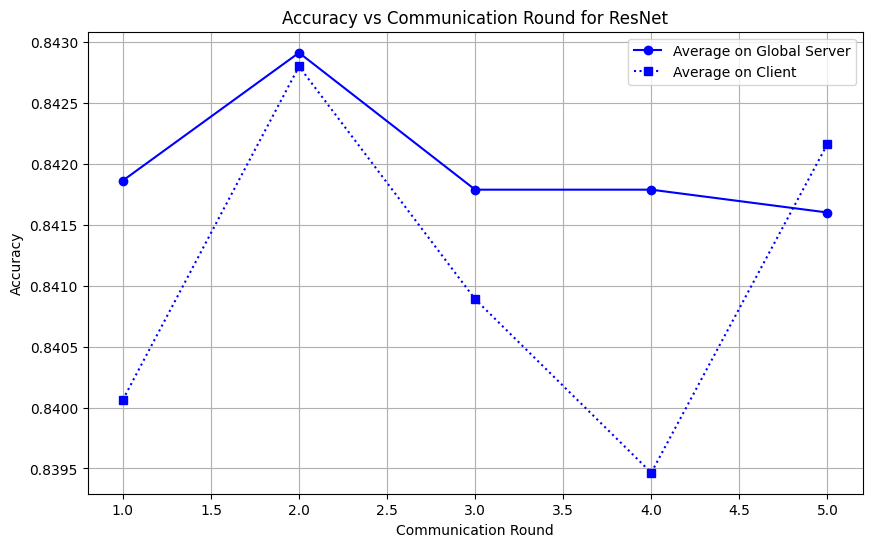

In [ ]:
#model_types = ['EffNet', 'XceptionNet', 'ResNet'] # include all the model types tested
#model_names = ['EffNet', 'XceptionNet', 'ResNet'] # in case different names are used when saving, rename here
#model_colors = ['blue', 'orange', 'green'] # colors for plotting

model_types = ['ResNet']
model_names = ['ResNet']
model_colors = ['blue'] 

def plot_accuracies(global_accs, local_avg_accs, comm_rounds, model_type,
                            title='Accuracy vs Communication Round for Models',
                            xlabel='Communication Round', ylabel='Accuracy',
                            color='blue'):
    rounds = list(range(1, comm_rounds + 1))
    plt.figure(figsize=(10, 6))
    plt.plot(rounds, global_accs, label=f'Average on Global Server ({model_type})', marker='o', color=color, linestyle='-')
    plt.plot(rounds, local_avg_accs, label=f'Average on Client ({model_type})', marker='s', color=color, linestyle=':')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)

def plot_all_accuracies(comm_rounds):
    for i, model_type in enumerate(model_types):
        global_accs, local_avg_accs = test_local_global_models_comm_rounds(model_type, model_names[i], test_loader, loss_fn)
        plot_accuracies(global_accs, local_avg_accs, comm_rounds, model_type,,
                        title=f'Accuracy vs Communication Round for Models',
                        xlabel='Communication Round', ylabel='Accuracy',
                        color=model_colors[i])
    plt.show()

plot_all_accuracies(COMM_ROUNDS)
